# Single-Qubit Gates and Measurements
**Notebook:** Visualization and testing of Pauli gates, Hadamard, measurement bases, and CNOT

## Overview

This notebook introduces the fundamental building blocks of quantum circuits:

### Single-qubit gates (Pauli group)
| Gate | Matrix | Effect on $|0\rangle$ | Effect on $|1\rangle$ |
|------|--------|----------------------|----------------------|
| $X$ (NOT) | $\begin{pmatrix}0&1\\1&0\end{pmatrix}$ | $|1\rangle$ | $|0\rangle$ |
| $Y$ | $\begin{pmatrix}0&-1\\1&0\end{pmatrix}$ | $i|1\rangle$ | $-i|0\rangle$ |
| $Z$ (phase flip) | $\begin{pmatrix}1&0\\0&-1\end{pmatrix}$ | $|0\rangle$ | $-|1\rangle$ |
| $H$ (Hadamard) | $\frac{1}{\sqrt{2}}\begin{pmatrix}1&1\\1&-1\end{pmatrix}$ | $|+\rangle$ | $|-\rangle$ |

### Measurement bases
- **Computational basis** ($Z$-basis): measures $\{|0\rangle, |1\rangle\}$
- **Superposition basis** ($X$-basis): apply $H$ then measure — measures $\{|+\rangle, |-\rangle\}$

### Two-qubit gate: CNOT
The controlled-NOT gate flips the target qubit if and only if the control qubit is $|1\rangle$.
It is the key gate for creating **entanglement** — used here to make Bell states.

### Visualization
Qubit states are visualized on the **Bloch sphere**: a unit sphere where:
- North pole = $|0\rangle$, South pole = $|1\rangle$
- Equator = superposition states ($|+\rangle$, $|-\rangle$, $|i\rangle$, $|-i\rangle$)

In [ ]:
import os
from dotenv import load_dotenv
load_dotenv()

import qiskit as qk
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_bloch_multivector, plot_histogram
from math import pi

### 1.1 Pauli gates

$X\equiv \sigma_x = \left( \begin{array}{cc}
 0 & 1 \\
 1 & 0  
 \end{array}
 \right)  = |0\rangle\langle 1 | + |1\rangle\langle 0 |$ 
 
 $Z\equiv \sigma_z = \left( \begin{array}{cc}
 1 & 0 \\
 0 & -1  
 \end{array}
 \right)  = |0\rangle\langle 0 | - |1\rangle\langle 1 |$ 
 
 $Y\equiv - i\sigma_y = \left( \begin{array}{cc}
 0 & -1 \\
 1 & 0  
 \end{array}
 \right)  =  |1\rangle\langle 0 | - |0\rangle\langle 1 |$ 

### 1.2 Hadamard gate

 $H =  (X+ Z)/\sqrt{2} = \frac{1}{\sqrt{2}}\left( \begin{array}{cc}
 1 & 1 \\
 1 & -1  
 \end{array}
 \right)  = \frac{ |0\rangle + | 1\rangle  } {\sqrt{2}} \langle 0 | + 
                    \frac{  |0\rangle - 1\rangle } {\sqrt{2}} \langle 1 |$ 

## Visualization 

### X gate

In [ ]:
# Statevector computes the exact quantum state vector of the circuit (no sampling noise).
# plot_bloch_multivector renders each qubit's state as a point on the Bloch sphere.
# After X on q1: q0 stays at |0⟩ (north pole), q1 is flipped to |1⟩ (south pole).
sv = Statevector(qc)
plot_bloch_multivector(sv)

In [ ]:
sv = Statevector(qc)
plot_bloch_multivector(sv)

### Y gate

In [ ]:
# Both qubits start in |0⟩, then H puts each on the equator (|+⟩ state).
# Y gate on q1 rotates it: on the equator H|0⟩=|+⟩, Y|+⟩ = i|−⟩ (180° rotation about Y axis).
# Statevector gives the exact amplitudes; Bloch sphere shows the resulting directions.
sv = Statevector(qc)
plot_bloch_multivector(sv)

In [ ]:
sv = Statevector(qc)
plot_bloch_multivector(sv)

### Z gate

In [ ]:
# After H on both qubits, each is in |+⟩ (equator, +X direction on Bloch sphere).
# Z gate on q1 maps |+⟩ → |−⟩ (flips the X-component: rotates 180° about Z axis).
# Statevector captures this analytically; Bloch sphere shows q1 pointing in -X direction.
sv = Statevector(qc)
plot_bloch_multivector(sv)

In [ ]:
sv = Statevector(qc)
plot_bloch_multivector(sv)

 Excersise: how can we represent the Hadamard gate in terms of rotations ? 

$H =  (X+ Z)/\sqrt{2} = \frac{1}{\sqrt{2}}\left( \begin{array}{cc}
 1 & 1 \\
 1 & -1  
 \end{array}
 \right)  = ?$ 

Answer: $H = X (1+ X Z)/\sqrt{2} =  X (1 + Y)/\sqrt{2} = X e^{ \pi Y/4 } = i  e^{-i \pi X/2 } e^{ \pi Y/4 }  $ 

In [ ]:
# Circuit: q1 gets H then X (= H·X, equivalent to half a Hadamard decomposition).
#          q2 gets just H, leaving it in |+⟩.
# Statevector shows the combined 3-qubit state; each qubit's reduced state appears on its Bloch sphere.
sv = Statevector(qc)
plot_bloch_multivector(sv)

In [ ]:
sv = Statevector(qc)
plot_bloch_multivector(sv)

Excersise: Calculate $HZH=?$

$H =  (X+ Z)/\sqrt{2} $ 

### 1.3 Measurement gate

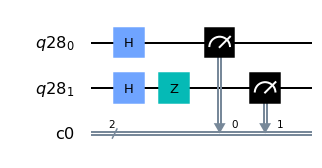

In [53]:
qr=qk.QuantumRegister(2)
cr=qk.ClassicalRegister(2)
qc=qk.QuantumCircuit(qr,cr)
qc.h(0)
qc.h(1)
qc.z(1)

measureZ=qk.QuantumCircuit(qr,cr)
measureZ.measure(qr,cr)
testZ=qc+measureZ
testZ.draw('mpl')

## Test of 1-Qubit gates

#### Qconfig_IBMQ_experience.py is file where you put the credentials in the form: 
#### APItoken = '' 
#### To get the token register at https://quantum-computing.ibm.com/account 

In [ ]:
# --- IBM Quantum hardware setup (Qiskit 1.x / qiskit-ibm-runtime) ---
# Run once to save your token:
#   from qiskit_ibm_runtime import QiskitRuntimeService
#   QiskitRuntimeService.save_account(channel='ibm_quantum', token='YOUR_TOKEN', overwrite=True)

from qiskit_ibm_runtime import QiskitRuntimeService
# service = QiskitRuntimeService(channel='ibm_quantum', token=os.environ.get('IBM_QUANTUM_TOKEN'))
print("IBM Quantum credentials: uncomment the line above after setting IBM_QUANTUM_TOKEN in .env")

####   Alternatively you can insert token directly:             

In [4]:
#IBMQ.enable_account("your token here")

<AccountProvider for IBMQ(hub='ibm-q', group='open', project='main')>

#### See which backends are available

In [ ]:
# List available backends (new API):
# service = QiskitRuntimeService(channel='ibm_quantum')
# print(service.backends())
backend_sim = AerSimulator()
print("Using local AerSimulator backend")

#### Choose the backend you like

#### Check which backend is less buisy

In [ ]:
# Find least-busy real device (new API):
# from qiskit_ibm_runtime import QiskitRuntimeService
# service = QiskitRuntimeService(channel='ibm_quantum')
# backend_real = service.least_busy(operational=True, simulator=False, min_num_qubits=5)
# print("Least busy:", backend_real.name)
print("(Real device selection requires IBM Quantum account)")

In [ ]:
backend = AerSimulator()

### Let's now write the code for simplest gates

#### Create 2 Qbits and 2 classical measurement gates

In [57]:
qr=qk.QuantumRegister(2)
cr=qk.ClassicalRegister(2)
qc=qk.QuantumCircuit(qr,cr)


### Prepare the state of  Qbits
#### Initially all Qbits are in |0> state


In [58]:
qc.x(qr[0])
#qc.x(qr[1])

In [ ]:
# Computational (Z) basis measurement: directly collapses each qubit to |0⟩ or |1⟩.
# This is the standard measurement; outcome probabilities are |α|² and |β|² for state α|0⟩+β|1⟩.
measureZ=qk.QuantumCircuit(qr,cr)
measureZ.measure(qr,cr)
testZ=qc+measureZ

In [59]:
measureZ=qk.QuantumCircuit(qr,cr)
measureZ.measure(qr,cr)
testZ=qc+measureZ

In [ ]:
# Superposition (X) basis measurement: apply H before measuring.
# H rotates the X-basis {|+⟩, |−⟩} into the computational basis {|0⟩, |1⟩}.
# So this circuit distinguishes |+⟩ from |−⟩ rather than |0⟩ from |1⟩.
# A qubit in |0⟩ or |1⟩ will give a 50/50 result here (maximum uncertainty in X-basis).
measureX=qk.QuantumCircuit(qr,cr)
measureX.h(qr)
measureX.measure(qr,cr)
testX=qc+measureX

In [60]:
measureX=qk.QuantumCircuit(qr,cr)
measureX.h(qr)
measureX.measure(qr,cr)
testX=qc+measureX

#### Run the jobs

Choose the local simulator

In [ ]:
backend = AerSimulator()
jobIBM = backend.run(transpile([testZ, testX], backend), shots=1024)
resultSim = jobIBM.result()

Coose the cloud backend

In [ ]:
# Run on real IBM device (requires account setup above):
# from qiskit_ibm_runtime import SamplerV2 as Sampler
# backend_real = service.least_busy(operational=True, simulator=False, min_num_qubits=2)
# sampler = Sampler(backend_real)
# job = sampler.run([transpile(testZ, backend_real), transpile(testX, backend_real)], shots=1024)
# counts_Z = job.result()[0].data.c.get_counts()
# counts_X = job.result()[1].data.c.get_counts()

# Using simulator results as stand-in
resultExp = resultSim
print("Note: using simulator results. Uncomment block above for real hardware.")

#### Plot results as histograms

Computational basis

In [ ]:
from qiskit.visualization import plot_histogram
plot_histogram([resultExp.get_counts(testZ), resultSim.get_counts(testZ)],
               legend=['Real device (or sim)', 'Simulator'])

Superposition basis

In [ ]:
from qiskit.visualization import plot_histogram
plot_histogram([resultExp.get_counts(testX), resultSim.get_counts(testX)],
               legend=['Real device (or sim)', 'Simulator'])

####  Check what happens if we apply several times

In [ ]:
qr = qk.QuantumRegister(2)
cr = qk.ClassicalRegister(2)
qc = qk.QuantumCircuit(qr, cr)

# Apply X gate 11 times to qr[0] (odd → |1⟩), 10 times to qr[1] (even → |0⟩)
for _ in range(11):
    qc.x(qr[0])
for _ in range(10):
    qc.x(qr[1])

measureZ = qk.QuantumCircuit(qr, cr)
measureZ.measure(qr, cr)
testZ = qc + measureZ

# Simulate
backend_sim = AerSimulator()
jobSim = backend_sim.run(transpile(testZ, backend_sim), shots=1024)
resultSimMulty = jobSim.result()
resultExpMulty = resultSimMulty   # placeholder (use real device block in cell-47 pattern)

from qiskit.visualization import plot_histogram
plot_histogram([resultExpMulty.get_counts(testZ), resultSimMulty.get_counts(testZ)],
               legend=['Real device (or sim)', 'Simulator'])

###  Let's check CNOT gate
####  Let's choose Qbits 0 as controlling one and Qbit 1 as the target one. 

In [ ]:
qr = qk.QuantumRegister(2)
cr = qk.ClassicalRegister(2)
qc = qk.QuantumCircuit(qr, cr)

# Step 1: H on q0 creates superposition: q0 → (|0⟩+|1⟩)/√2, q1 stays |0⟩.
# Step 2: CNOT with q0 as control, q1 as target.
#   When q0=|0⟩: q1 unchanged; when q0=|1⟩: q1 flipped.
#   Result: (|00⟩ + |11⟩)/√2  — the Bell state |Φ+⟩.
# This is maximally entangled: measuring one qubit instantly determines the other.
qc.h(qr[0])
qc.cx(qr[0], qr[1])

# Z-basis measurement: should give only '00' or '11' (never '01' or '10') — signature of entanglement.
measureZ = qk.QuantumCircuit(qr, cr)
measureZ.measure(qr, cr)
testZ = qc + measureZ

# X-basis measurement: H before measuring — entangled Bell state also shows correlations here.
measureX = qk.QuantumCircuit(qr, cr)
measureX.h(qr)
measureX.measure(qr, cr)
testX = qc + measureX

# Simulate
backend_sim = AerSimulator()
jobSim = backend_sim.run(transpile([testZ, testX], backend_sim), shots=1024)
resultSimCNOT = jobSim.result()
resultExpCNOT = resultSimCNOT   # placeholder

from qiskit.visualization import plot_histogram
plot_histogram([resultExpCNOT.get_counts(testZ), resultSimCNOT.get_counts(testZ)],
               legend=['Real device (or sim)', 'Simulator (Z basis)'])

In [ ]:
qr = qk.QuantumRegister(2)
cr = qk.ClassicalRegister(2)
qc = qk.QuantumCircuit(qr, cr)

# Create Bell state |Φ+⟩ = (|00⟩ + |11⟩)/√2
qc.h(qr[0])
qc.cx(qr[0], qr[1])

measureZ = qk.QuantumCircuit(qr, cr)
measureZ.measure(qr, cr)
testZ = qc + measureZ

measureX = qk.QuantumCircuit(qr, cr)
measureX.h(qr)
measureX.measure(qr, cr)
testX = qc + measureX

# Simulate
backend_sim = AerSimulator()
jobSim = backend_sim.run(transpile([testZ, testX], backend_sim), shots=1024)
resultSimCNOT = jobSim.result()
resultExpCNOT = resultSimCNOT   # placeholder

from qiskit.visualization import plot_histogram
plot_histogram([resultExpCNOT.get_counts(testZ), resultSimCNOT.get_counts(testZ)],
               legend=['Real device (or sim)', 'Simulator (Z basis)'])

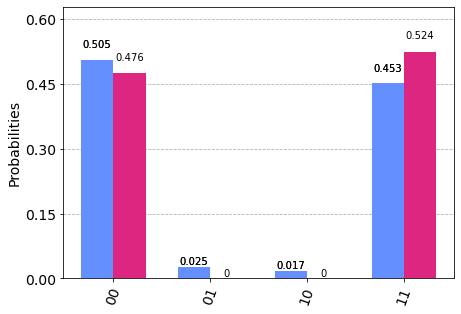

In [95]:
from qiskit.visualization import plot_histogram
plot_histogram([resultExpCNOT.get_counts(testZ),resultSimCNOT.get_counts(testZ)])